# Interaction Evolution Animation

This notebook loads model snapshots from different training epochs and creates an animated visualization showing how pairwise and any-order interaction strengths evolve during training.

In [15]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Force reload of modified modules
import importlib
import multilayer_perceptron
import neural_interaction_detection
import utils
importlib.reload(multilayer_perceptron)
importlib.reload(neural_interaction_detection)
importlib.reload(utils)

from multilayer_perceptron import MLP, train, get_weights
from neural_interaction_detection import get_interactions, interactions_to_matrix
from utils import preprocess_data, load_snapshots, create_interaction_animation
import synth

## Configuration

In [16]:
# Configuration
NUM_FEATURES = 10
NUM_SAMPLES = 30000
HIDDEN_UNITS = [140, 100, 60, 20]
USE_MAIN_EFFECT_NETS = True

# Training settings
NEPOCHS = 200
LEARNING_RATE = 1e-2
L1_CONST = 5e-5

# Snapshot settings (toggle this to enable/disable saving)
SAVE_SNAPSHOTS = True
SNAPSHOT_DIR = "./outputs/snapshots/animation"
SNAPSHOT_EPOCHS = [i for i in range(0, 201, 5)]  # Save every 5 epochs

# Variable labels (x_1 to x_10)
LABELS = [f"x_{i}" for i in range(1, NUM_FEATURES + 1)]

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## Generate synthetic data and train model with snapshots

In [17]:
# Generate data using synth (F3 - mixed interactions)
X, Y, gt = synth.functions[3](num_samples=NUM_SAMPLES, seed=42, noise_std= 0.1)
data_loaders = preprocess_data(X, Y, valid_size=10000, test_size=10000, 
                                std_scale=True, get_torch_loaders=True)

print(f"Data shape: X={X.shape}, Y={Y.shape}")
print(f"Ground truth pairwise interactions: {gt['pairwise']}")
print(f"Ground truth any-order interactions: {gt['any_order']}")

Data shape: X=(30000, 10), Y=(30000,)
Ground truth pairwise interactions: [(0, 1), (2, 4), (5, 6), (5, 7), (6, 7)]
Ground truth any-order interactions: [(0, 1), (2, 4), (5, 6, 7)]


In [18]:
# Create and train model with snapshot saving enabled
model = MLP(NUM_FEATURES, HIDDEN_UNITS, use_main_effect_nets=USE_MAIN_EFFECT_NETS).to(device)

# Train with save_snapshots=True to capture weights at each epoch
result = train(
    model, 
    data_loaders, 
    device=device,
    nepochs=NEPOCHS,
    learning_rate=LEARNING_RATE,
    l1_const=L1_CONST,
    verbose=True,
    early_stopping=False,  # Disable to train all epochs
    save_snapshots=SAVE_SNAPSHOTS,
    snapshot_epochs=SNAPSHOT_EPOCHS,
    snapshot_dir=SNAPSHOT_DIR
)

# Unpack results (3 values when snapshots enabled)
if SAVE_SNAPSHOTS:
    model, test_loss, snapshots = result
    print(f"\nSnapshots saved for epochs: {sorted(snapshots.keys())}")
else:
    model, test_loss = result
    snapshots = {}

print(f"Final test loss: {test_loss:.4f}")

starting to train
saving snapshots at epochs: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200]
[epoch 1, total 200] train loss: 0.1013, val loss: 0.0207
[epoch 3, total 200] train loss: 0.0193, val loss: 0.0162
  → Snapshot saved: ./outputs/snapshots/animation/model_epoch_5.pt
[epoch 5, total 200] train loss: 0.0186, val loss: 0.0151
[epoch 7, total 200] train loss: 0.0183, val loss: 0.0165
[epoch 9, total 200] train loss: 0.0164, val loss: 0.0157
  → Snapshot saved: ./outputs/snapshots/animation/model_epoch_10.pt
[epoch 11, total 200] train loss: 0.0174, val loss: 0.0141
[epoch 13, total 200] train loss: 0.0157, val loss: 0.0197
  → Snapshot saved: ./outputs/snapshots/animation/model_epoch_15.pt
[epoch 15, total 200] train loss: 0.0141, val loss: 0.0123
[epoch 17, total 200] train loss: 0.0152, val loss: 0.0155
[epoch 19, total 200] train loss: 0.0147,

## Load snapshots and compute interactions

In [19]:
# Load snapshots from disk if not available in memory
if 'snapshots' not in dir() or not snapshots:
    snapshots = load_snapshots(SNAPSHOT_DIR, SNAPSHOT_EPOCHS)
    print(f"Loaded {len(snapshots)} snapshots from disk")

# Compute interactions for all saved snapshots
pairwise_matrices = {}
anyorder_matrices = {}

for epoch, state_dict in sorted(snapshots.items()):
    # Load weights into a fresh model
    temp_model = MLP(NUM_FEATURES, HIDDEN_UNITS, use_main_effect_nets=USE_MAIN_EFFECT_NETS)
    temp_model.load_state_dict(state_dict)
    temp_model.eval()
    
    # Get weights and compute interactions
    weights = get_weights(temp_model)
    pairwise = get_interactions(weights, pairwise=True, one_indexed=True)
    anyorder = get_interactions(weights, pairwise=False, one_indexed=True)
    
    pairwise_matrices[epoch] = interactions_to_matrix(pairwise, NUM_FEATURES)
    anyorder_matrices[epoch] = interactions_to_matrix(anyorder, NUM_FEATURES)
    
    print(f"Epoch {epoch:3d}: computed interactions")

available_epochs = sorted(pairwise_matrices.keys())
print(f"\nProcessed {len(available_epochs)} epochs: {available_epochs}")

Epoch   5: computed interactions
Epoch  10: computed interactions
Epoch  15: computed interactions
Epoch  20: computed interactions
Epoch  25: computed interactions
Epoch  30: computed interactions
Epoch  35: computed interactions
Epoch  40: computed interactions
Epoch  45: computed interactions
Epoch  50: computed interactions
Epoch  55: computed interactions
Epoch  60: computed interactions
Epoch  65: computed interactions
Epoch  70: computed interactions
Epoch  75: computed interactions
Epoch  80: computed interactions
Epoch  85: computed interactions
Epoch  90: computed interactions
Epoch  95: computed interactions
Epoch 100: computed interactions
Epoch 105: computed interactions
Epoch 110: computed interactions
Epoch 115: computed interactions
Epoch 120: computed interactions
Epoch 125: computed interactions
Epoch 130: computed interactions
Epoch 135: computed interactions
Epoch 140: computed interactions
Epoch 145: computed interactions
Epoch 150: computed interactions
Epoch 155:

## Create side-by-side animated heatmaps

In [20]:
# Determine global color scale for consistent comparison across epochs
all_pairwise = np.array([pairwise_matrices[e] for e in available_epochs])
all_anyorder = np.array([anyorder_matrices[e] for e in available_epochs])

vmin_pw, vmax_pw = 0, all_pairwise.max()
vmin_ao, vmax_ao = 0, all_anyorder.max()

print(f"Pairwise range:   0 – {vmax_pw:.2f}")
print(f"Any-order range:  0 – {vmax_ao:.2f}")

Pairwise range:   0 – 7.19
Any-order range:  0 – 8.87


In [21]:
# Create animation using helper function
fig, update = create_interaction_animation(
    pairwise_matrices, anyorder_matrices, available_epochs,
    LABELS, vmax_pw, vmax_ao
)

ani = FuncAnimation(fig, update, frames=len(available_epochs), interval=600, blit=False)
plt.close(fig)  # Prevent duplicate static display

HTML(ani.to_jshtml())

## Save animation as GIF / MP4

In [ ]:
# Save as GIF (requires pillow)
os.makedirs("outputs", exist_ok=True)
gif_path = "outputs/interaction_evolution.gif"

# Recreate animation for saving
fig2, update2 = create_interaction_animation(
    pairwise_matrices, anyorder_matrices, available_epochs,
    LABELS, vmax_pw, vmax_ao
)

ani2 = FuncAnimation(fig2, update2, frames=len(available_epochs), interval=600, blit=False)
ani2.save(gif_path, writer="pillow", fps=2)
plt.close(fig2)

print(f"Animation saved to: {gif_path}")

Animation saved to: outputs/interaction_evolution.gif


## Static grid view (all epochs at once)

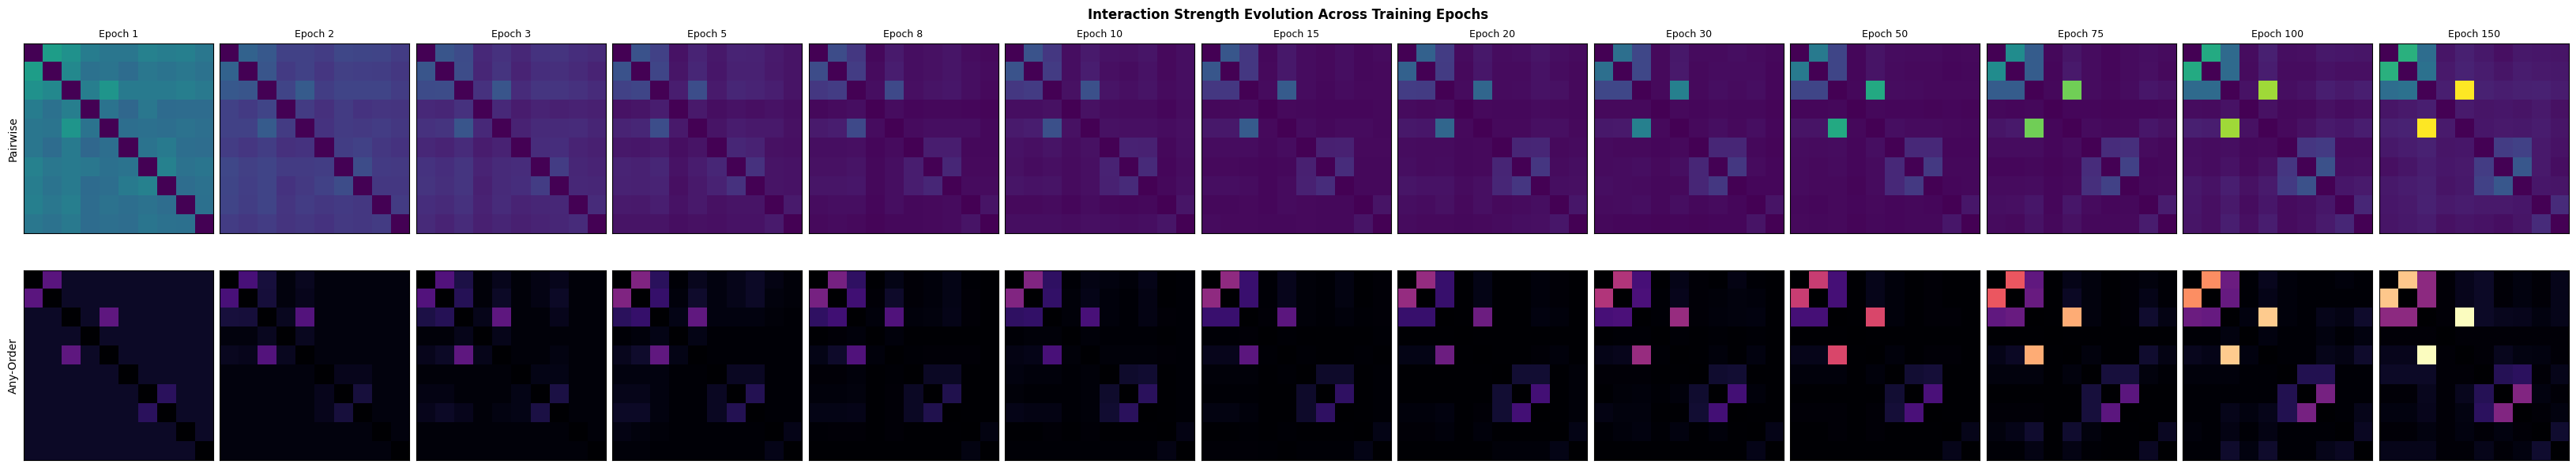

Static grid saved to: outputs/interaction_evolution_grid.png


In [26]:
n_epochs = len(available_epochs)
fig3, axes3 = plt.subplots(2, n_epochs, figsize=(2.5 * n_epochs, 6), constrained_layout=True)

for col, epoch in enumerate(available_epochs):
    # Pairwise (top row)
    ax_pw = axes3[0, col]
    ax_pw.imshow(pairwise_matrices[epoch], cmap="viridis", vmin=vmin_pw, vmax=vmax_pw)
    ax_pw.set_title(f"Epoch {epoch}", fontsize=9)
    ax_pw.set_xticks([])
    ax_pw.set_yticks([])
    
    # Any-order (bottom row)
    ax_ao = axes3[1, col]
    ax_ao.imshow(anyorder_matrices[epoch], cmap="magma", vmin=vmin_ao, vmax=vmax_ao)
    ax_ao.set_xticks([])
    ax_ao.set_yticks([])

axes3[0, 0].set_ylabel("Pairwise", fontsize=10)
axes3[1, 0].set_ylabel("Any-Order", fontsize=10)

fig3.suptitle("Interaction Strength Evolution Across Training Epochs", fontsize=12, fontweight="bold")

static_path = "outputs/interaction_evolution_grid.png"
fig3.savefig(static_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Static grid saved to: {static_path}")